In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import Axes
from helpers import get_years_dfs

In [2]:
import seaborn as sns
sns.set_theme(context="paper", font_scale=2)

In [3]:
def get_full_df(input_path: str):
    return pd.concat(get_years_dfs(input_path))

In [4]:
summary_cols = ["WC", "Analytic", "Clout", "Authentic", "Tone", "WPS", "BigWords", "Dic", "Linguistic"]

def get_summary_df(df: pd.DataFrame):
    """Create a summary dataframe that has years as rows and each summary LIWC stat as columns, 
    with the mean value for the LIWC stat over the year in each cell."""
    return df.groupby("year")[summary_cols].mean()

In [17]:
def save_summary_plots(df: pd.DataFrame, graph_title: str, save_path: str):
    # Create a figure with 9 subplots, 3 rows by 3 columns
    fig, axes = plt.subplots(
        nrows=3, ncols=3, 
        figsize=(36, 18), 
        squeeze=False)

    fig.suptitle(graph_title, fontsize=32)

    # Get the axes as a flat list so that they're easily accessible.
    # These axes represent each subplot.
    axes_flat: list[Axes] = axes.flatten()

    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        
        # Years on the x-axis
        # Summary stat on the y-axis
        # Dot markers for each point
        # Line width 3
        # Marker size 10
        ax.plot(df.index, df[col], marker="o", lw=3, markersize=10)
        
        ax.set_title(col)
        
        ax.set_xlabel("year")
        ax.set_xticks(range(2009, 2025))
        ax.tick_params(axis="x", rotation=45)
        
        ax.grid(True)

    plt.tight_layout()

    plt.draw()
    plt.savefig(save_path)

    plt.show()

In [18]:
all_types_summary_df = get_summary_df(
    get_full_df("./output/liwc.xlsx")
)
all_types_summary_df

,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic
year,,,,,,,,,
2009,648.941176,84.165882,45.388235,26.257647,24.760000,23.154706,28.235882,84.844706,60.658235
2010,443.304348,82.992609,52.803478,22.998261,35.765455,20.226522,26.435652,81.612609,57.535217
2011,507.250000,83.552045,61.062273,26.005909,34.137500,22.592727,27.156136,83.483864,58.890455
2012,566.000000,87.317143,60.870357,19.583929,31.674286,21.365000,28.110357,83.452500,57.253214
2013,539.622951,79.440984,59.418833,28.647705,28.973036,19.276885,27.990328,83.361311,57.813770
2014,418.294118,82.773824,56.226667,26.218235,33.654242,21.054412,25.184412,82.224706,57.278529
2015,527.119048,82.240714,55.992750,30.130714,24.864324,18.880952,26.827381,82.610476,57.945476
2016,364.527473,78.662637,59.035682,29.864667,34.282024,19.416813,24.898791,83.050549,59.298681
2017,317.869955,78.774529,63.038178,28.725964,28.723950,19.562646,25.012063,82.270404,58.475919


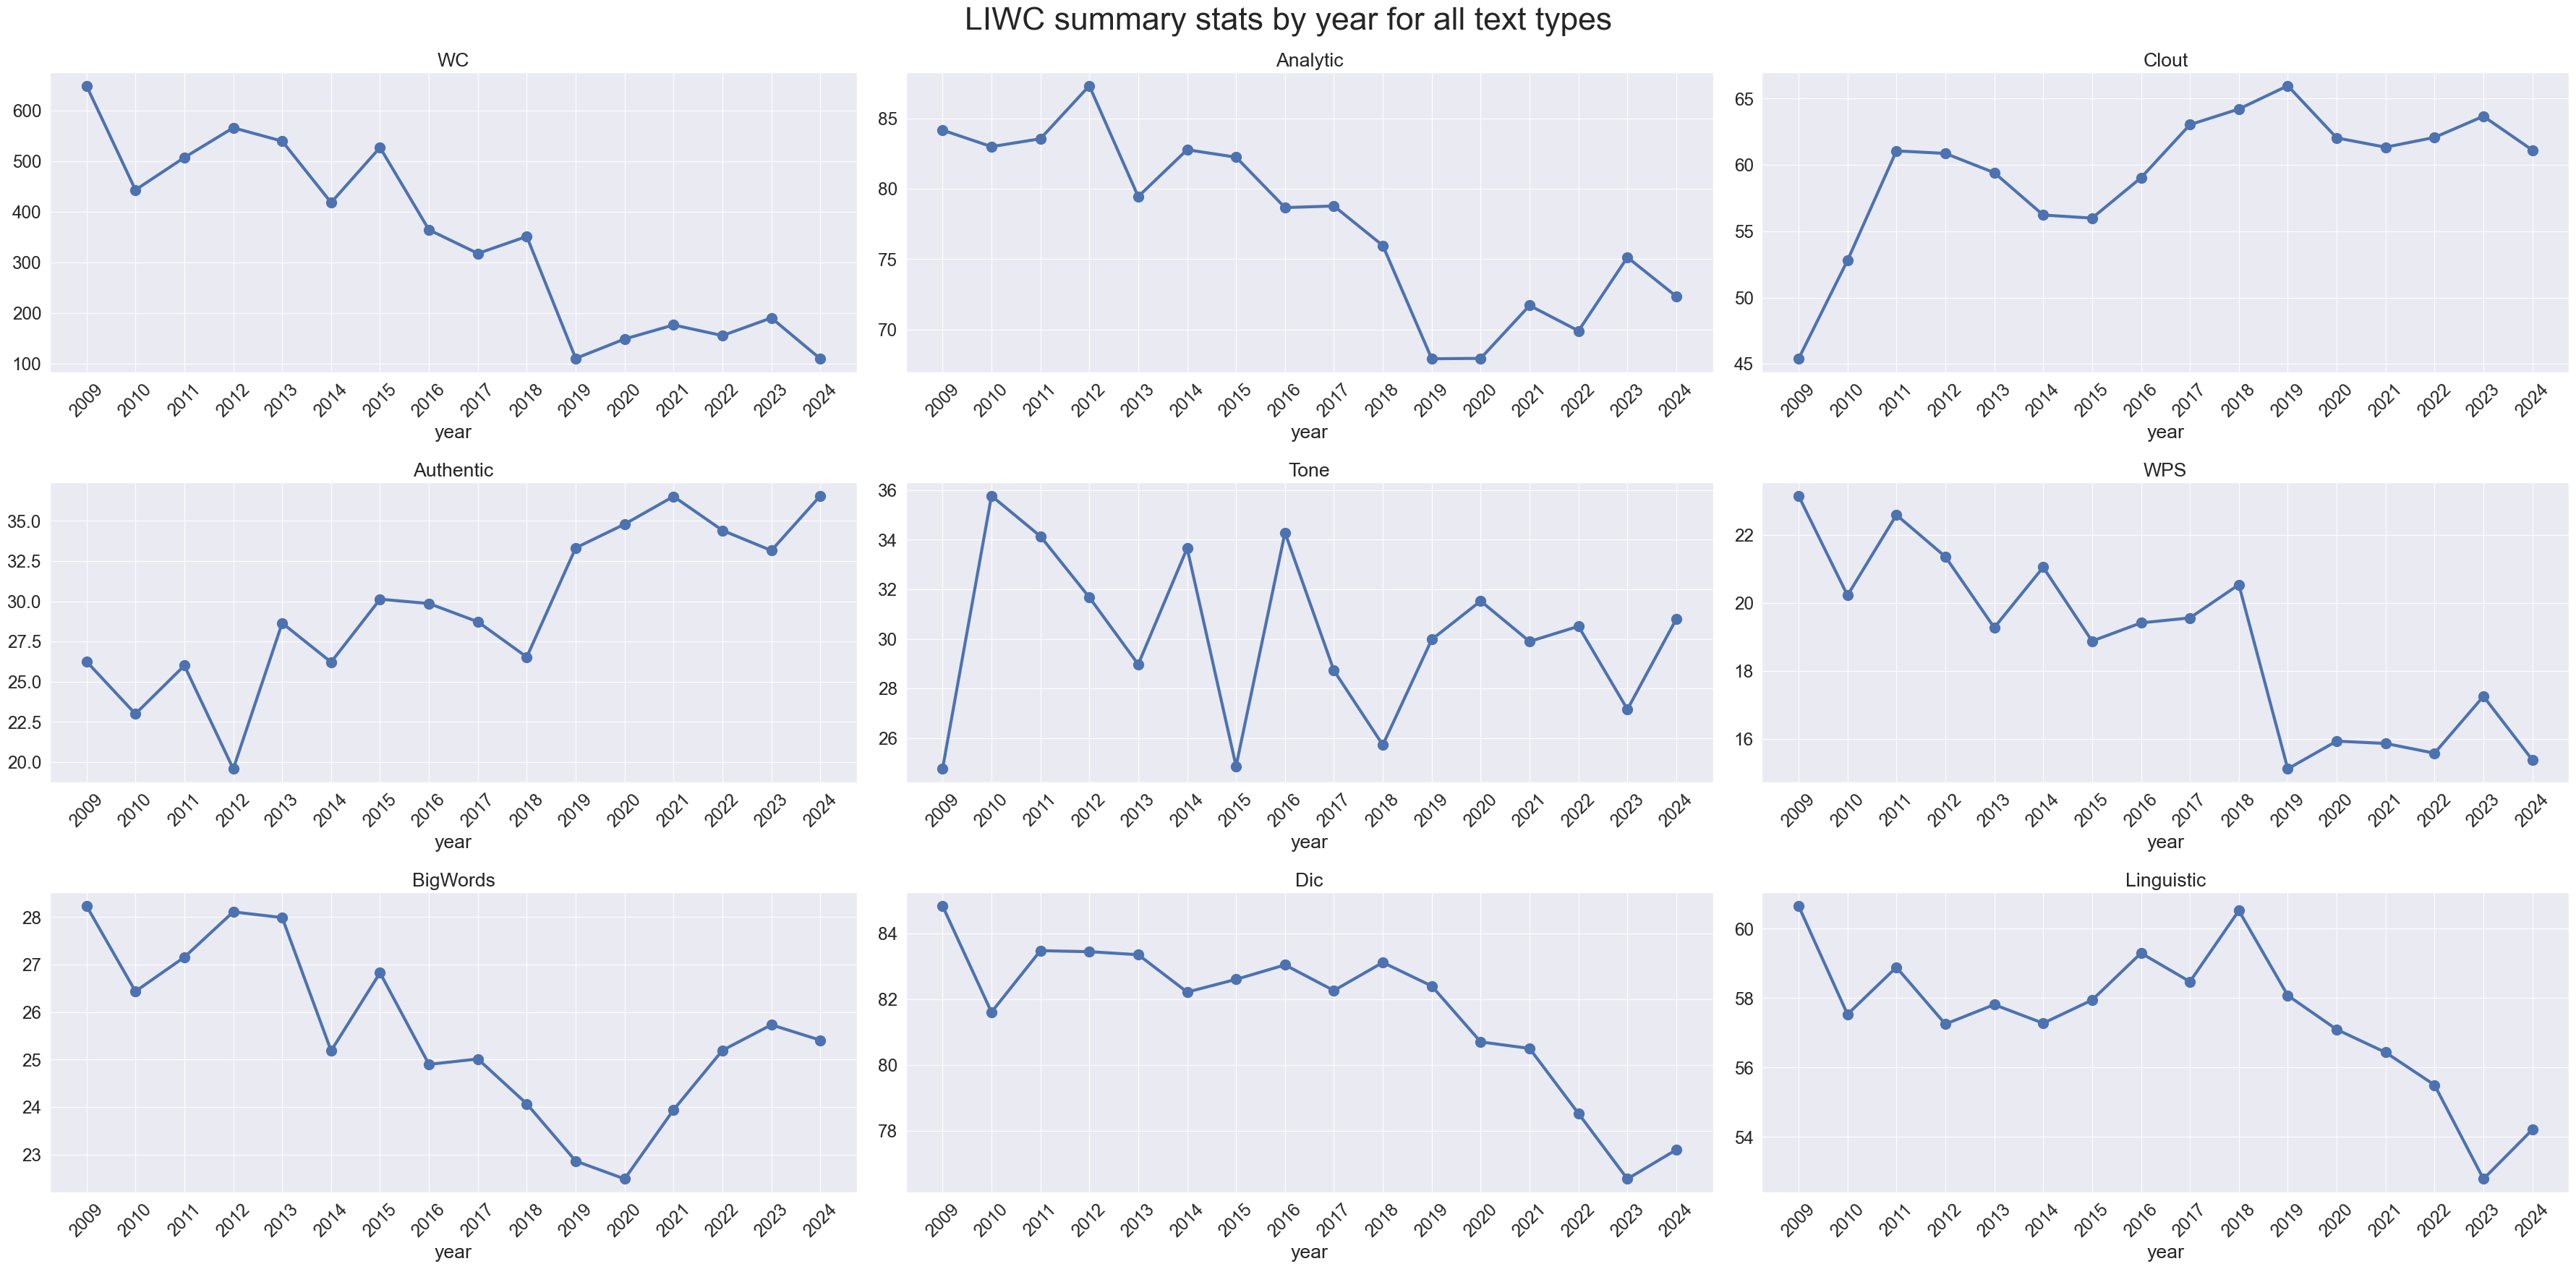

In [19]:
save_summary_plots(
    all_types_summary_df, 
    save_path="./visualization/LIWC/summary_all_types.png",
    graph_title="LIWC summary stats by year for all text types"
)

In [20]:
news_and_blog_summary_df = get_summary_df(
    get_full_df("./output/news_and_blog/liwc_news_and_blog.xlsx")
)
news_and_blog_summary_df

,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic
year,,,,,,,,,
2009,668.454545,83.710909,43.484545,31.424545,20.069091,19.418182,26.130909,85.089091,61.930000
2010,605.214286,81.541429,54.364286,23.464286,29.737143,20.115714,25.130714,83.401429,59.597143
2011,579.518519,80.360000,59.994444,26.141481,36.873333,20.913704,26.464074,83.797037,60.003333
2012,669.125000,85.871250,57.796875,17.862500,30.340000,19.116250,28.431250,83.295000,58.353750
2013,798.264706,79.026471,60.822941,27.697647,26.607941,20.038235,26.268824,84.684412,60.817353
2014,546.294118,81.639412,53.987059,25.750588,24.892941,20.475294,24.756471,83.071176,60.098824
2015,759.695652,82.576087,57.676957,25.920870,22.837826,21.402174,25.952174,84.510000,60.207391
2016,597.553191,79.711915,60.611064,26.471702,29.669149,21.828936,25.271702,83.690426,60.271489
2017,395.128571,78.493857,66.345857,26.050714,24.479209,21.059929,24.172714,82.768357,60.312643


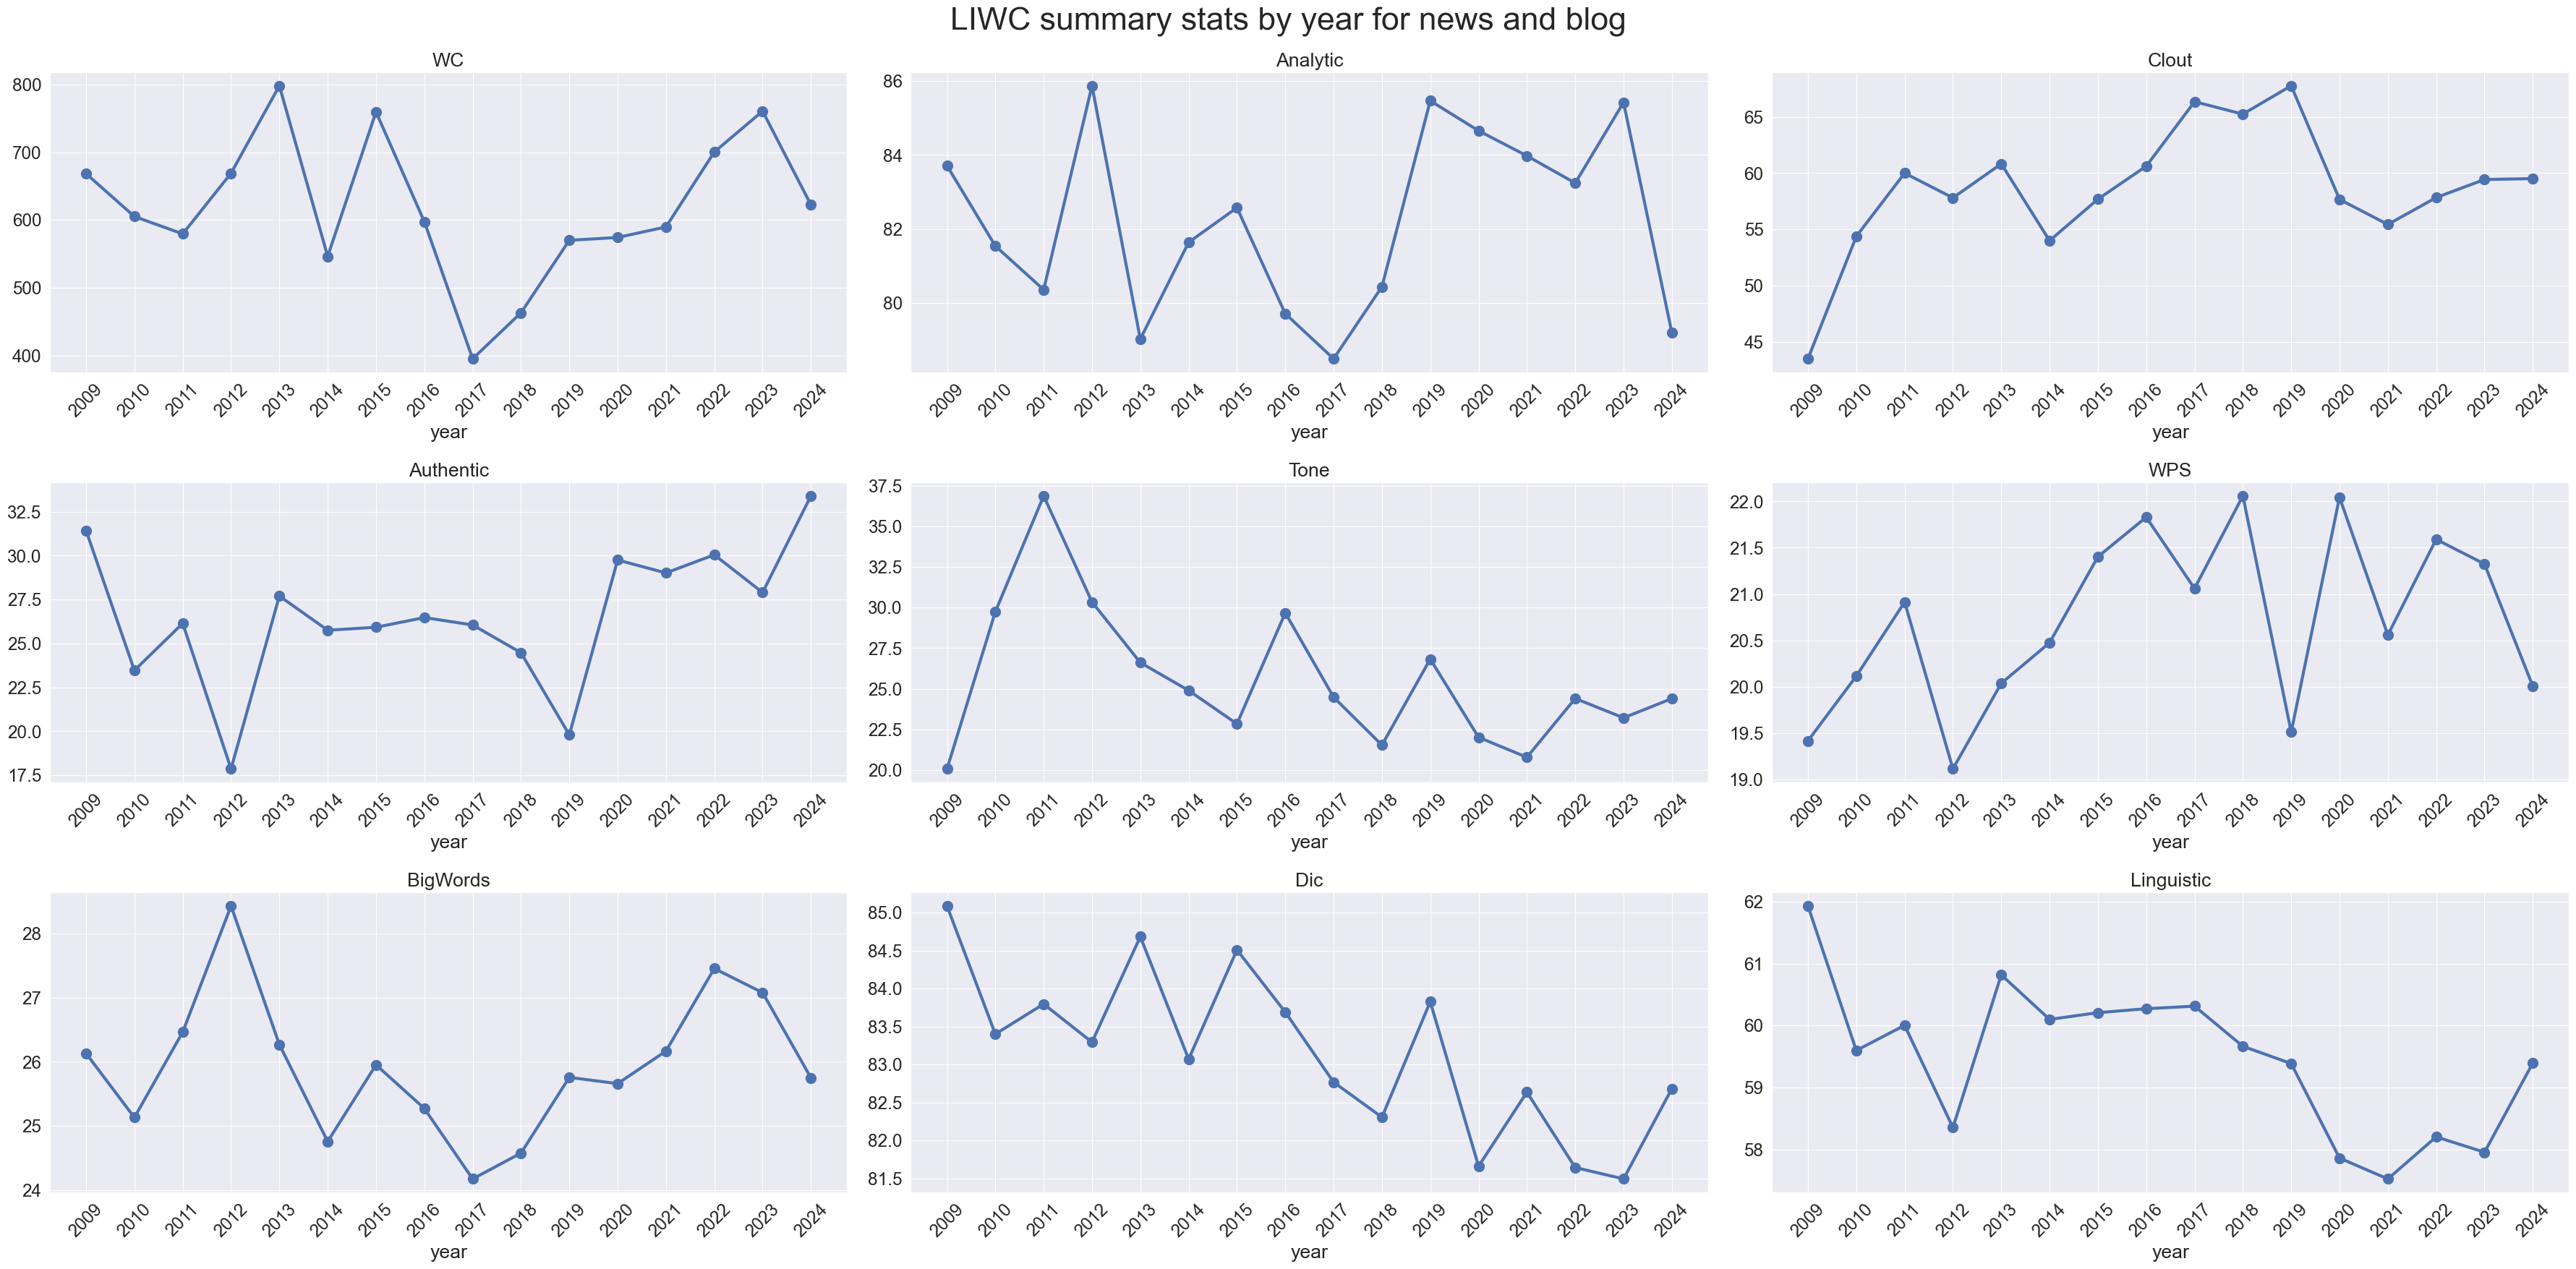

In [21]:
save_summary_plots(
    news_and_blog_summary_df, 
    save_path="./visualization/LIWC/summary_news_and_blog.png",
    graph_title="LIWC summary stats by year for news and blog")

In [22]:
press_release_summary_df = get_summary_df(
    get_full_df("./output/press_release/liwc_press_release.xlsx")
)
press_release_summary_df

,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic
year,,,,,,,,,
2009,531.600000,88.344000,48.896000,16.008000,28.792500,32.154000,32.932000,84.372000,58.180000
2010,214.750000,90.943750,56.547500,12.682500,46.315000,22.323750,27.023750,78.683750,53.618750
2011,392.470588,88.621765,62.758235,25.790588,29.792353,25.259412,28.255294,82.986471,57.122941
2012,428.500000,89.245000,64.968333,21.879167,33.453333,24.363333,27.682500,83.662500,55.785833
2013,318.411765,89.816471,62.606471,26.104118,40.720000,23.191765,30.562941,81.605882,55.537647
2014,429.090909,88.720000,59.683636,21.903636,31.475455,24.835455,29.093636,81.462727,53.409091
2015,452.285714,88.484286,65.871429,19.348571,38.137143,25.024286,28.505714,81.468571,55.680000
2016,290.571429,83.272143,60.850000,18.943571,32.749286,22.544286,29.575714,79.221429,54.169286
2017,710.055556,88.342778,52.958889,24.603889,35.820000,24.362778,30.366111,81.192222,54.373333


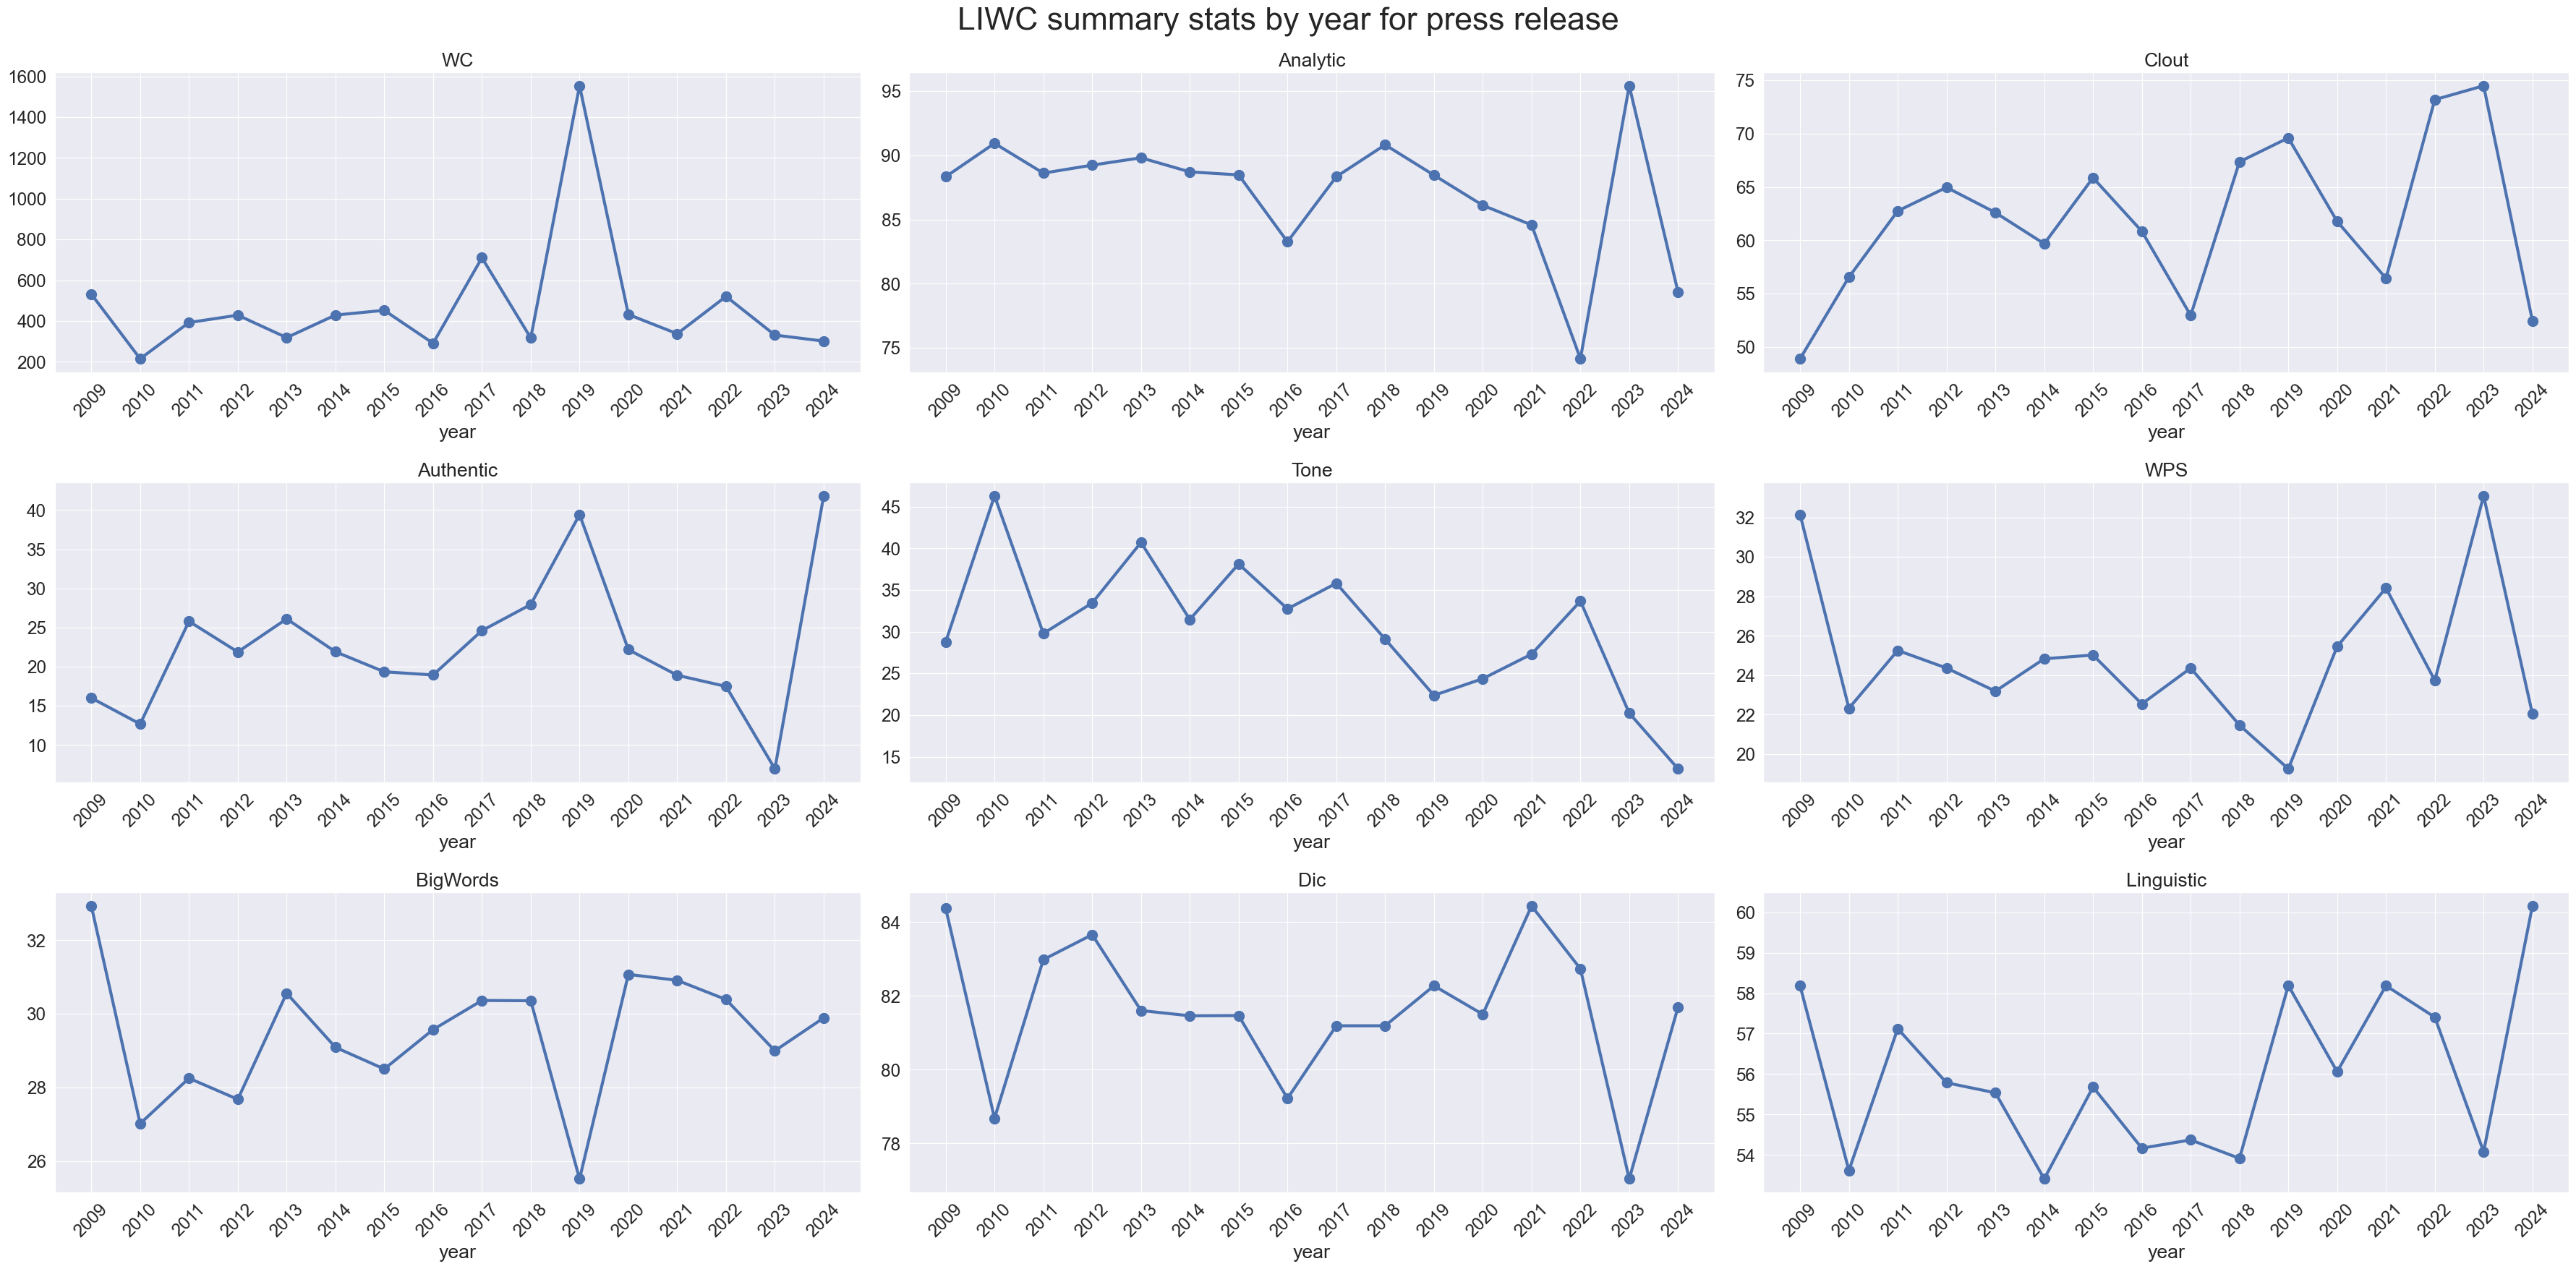

In [23]:
save_summary_plots(
    press_release_summary_df, 
    save_path="./visualization/LIWC/summary_press_release.png",
    graph_title="LIWC summary stats by year for press release"
)

In [24]:
social_media_summary_df = get_summary_df(
    get_full_df("./output/social_media/liwc_social_media.xlsx")
)
social_media_summary_df

,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic
year,,,,,,,,,
2009,1021.000000,68.280000,48.790000,20.670000,60.230000,19.260000,27.910000,84.520000,59.060000
2010,5.000000,39.700000,1.000000,99.000000,NaN,5.000000,40.000000,80.000000,60.000000
2013,36.300000,63.212000,48.093333,36.202000,5.116000,10.033000,29.470000,81.847000,51.471000
2014,35.833333,75.086667,56.236000,35.453333,68.236000,15.763333,19.230000,81.223333,56.381667
2015,125.000000,77.955833,45.204000,44.489167,18.250000,10.465000,27.525833,79.635833,54.931667
2016,33.966667,74.867667,55.352593,40.635862,44.641304,14.178333,22.132000,83.835000,60.168333
2017,42.861538,76.729385,58.008750,35.629538,39.474884,15.008462,25.337231,81.496462,55.656000
2018,43.366667,59.824333,60.575000,32.061000,37.888889,16.026000,21.159333,85.895667,64.497667
2019,54.861538,66.312752,65.776627,34.253520,30.427760,14.736923,22.609538,82.307731,57.980462


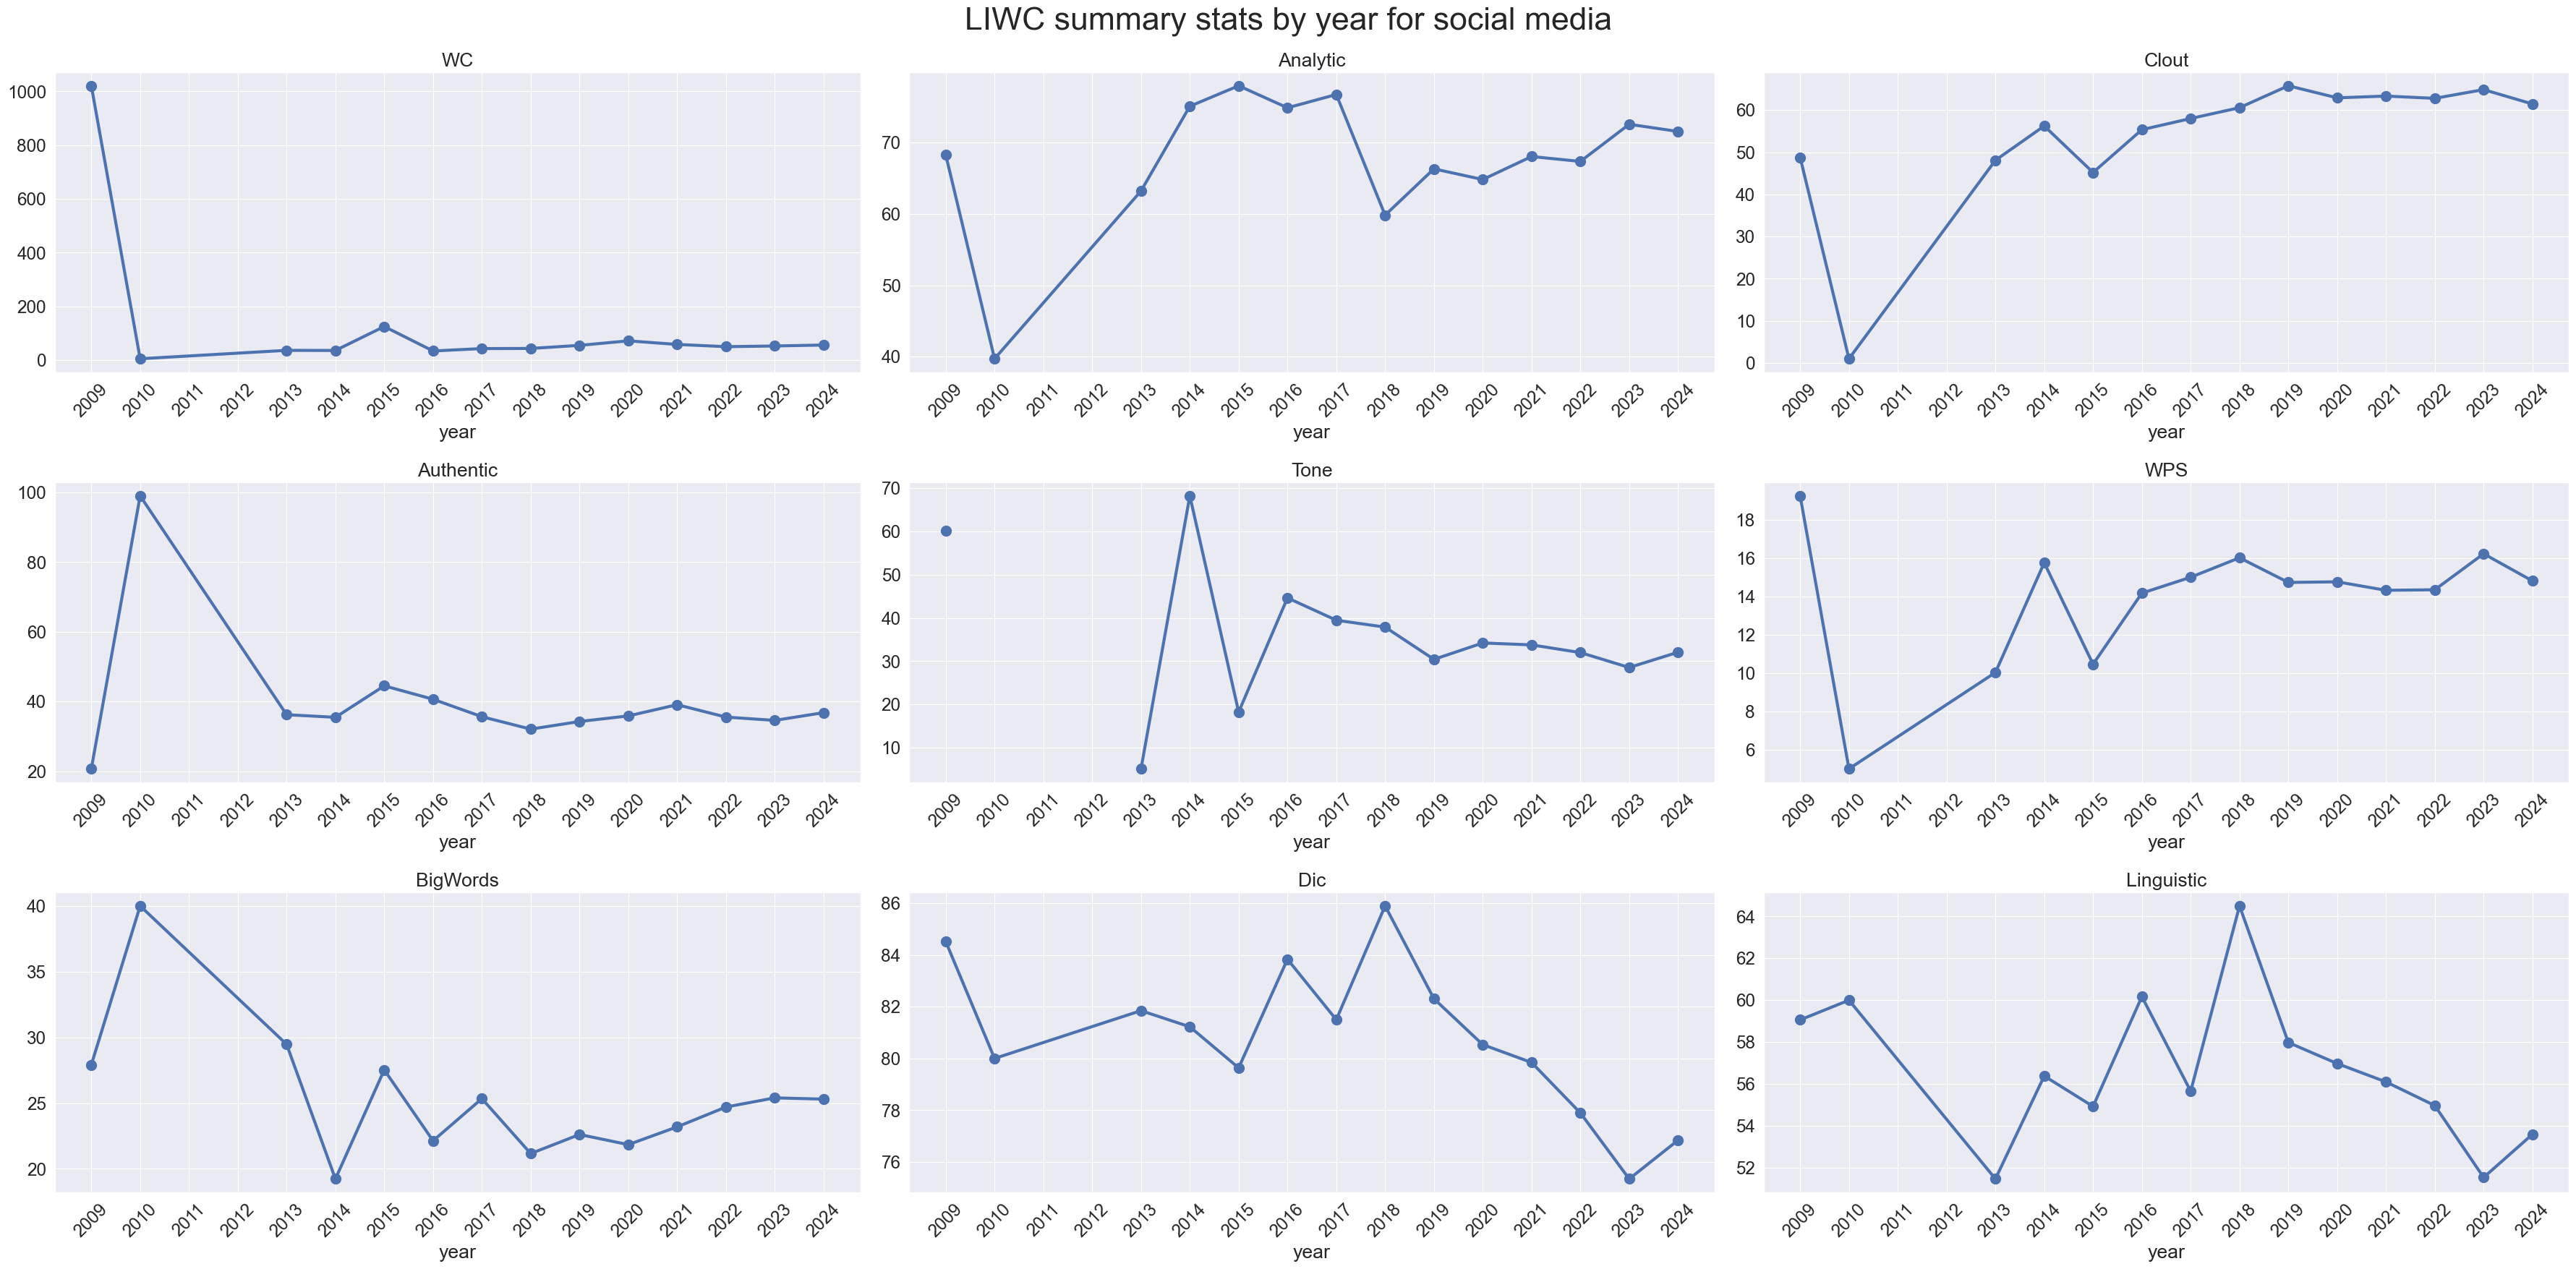

In [25]:
save_summary_plots(
    social_media_summary_df, 
    save_path="./visualization/LIWC/summary_social_media.png",
    graph_title="LIWC summary stats by year for social media"
)

### Some custom plots for the paper itself

WC, WPS, and BigWords

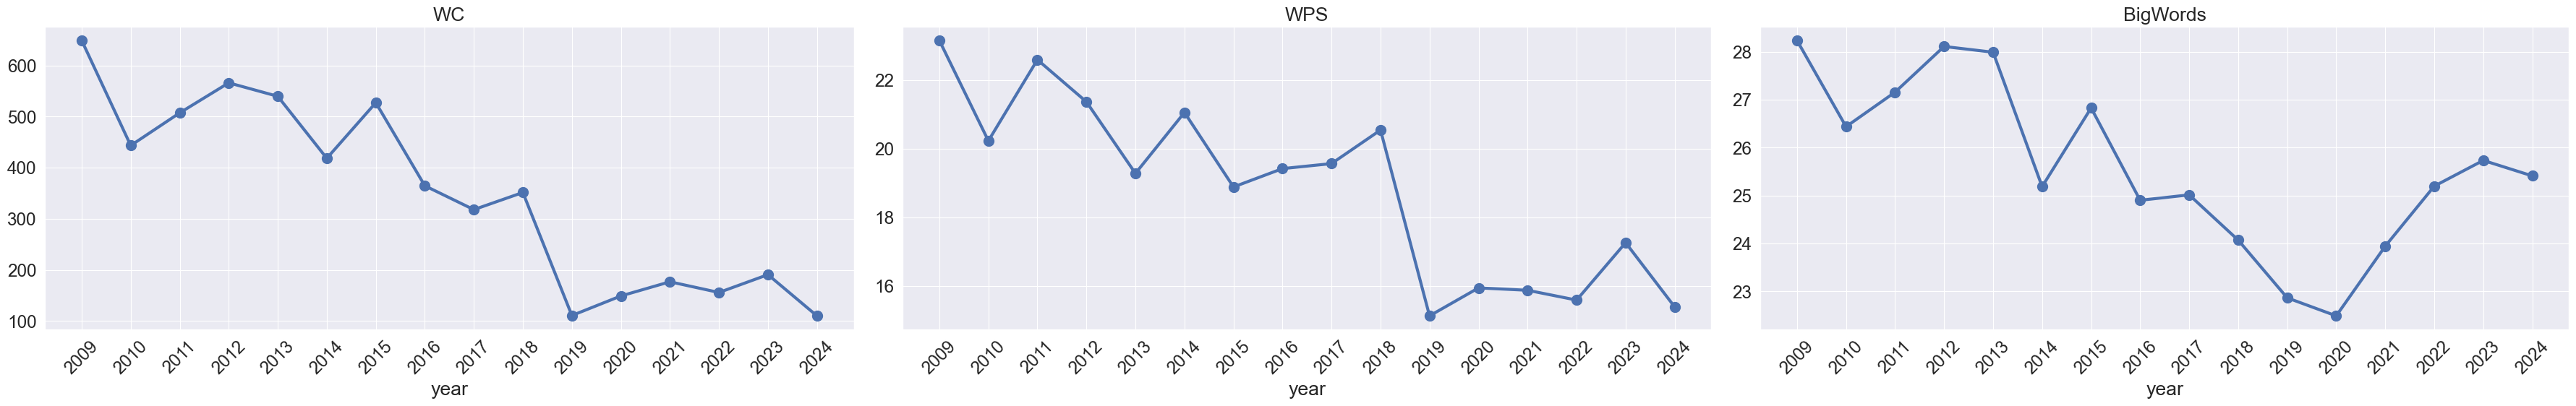

In [26]:
fig, axes = plt.subplots(
    nrows=1, ncols=3, 
    figsize=(36, 6), 
    squeeze=False)

axes_flat: list[Axes] = axes.flatten()

for i, col in enumerate(["WC", "WPS", "BigWords"]):
    ax = axes_flat[i]
    
    ax.plot(all_types_summary_df.index, all_types_summary_df[col], marker="o", lw=3, markersize=10)
    
    ax.set_title(col)
    
    ax.set_xlabel("year")
    ax.set_xticks(range(2009, 2025))
    ax.tick_params(axis="x", rotation=45)
    
    ax.grid(True)

plt.tight_layout()

plt.draw()
plt.savefig("./visualization/LIWC/paper_all_types_wc_wps_bigwords.png")

plt.show()

Dic and Linguistic

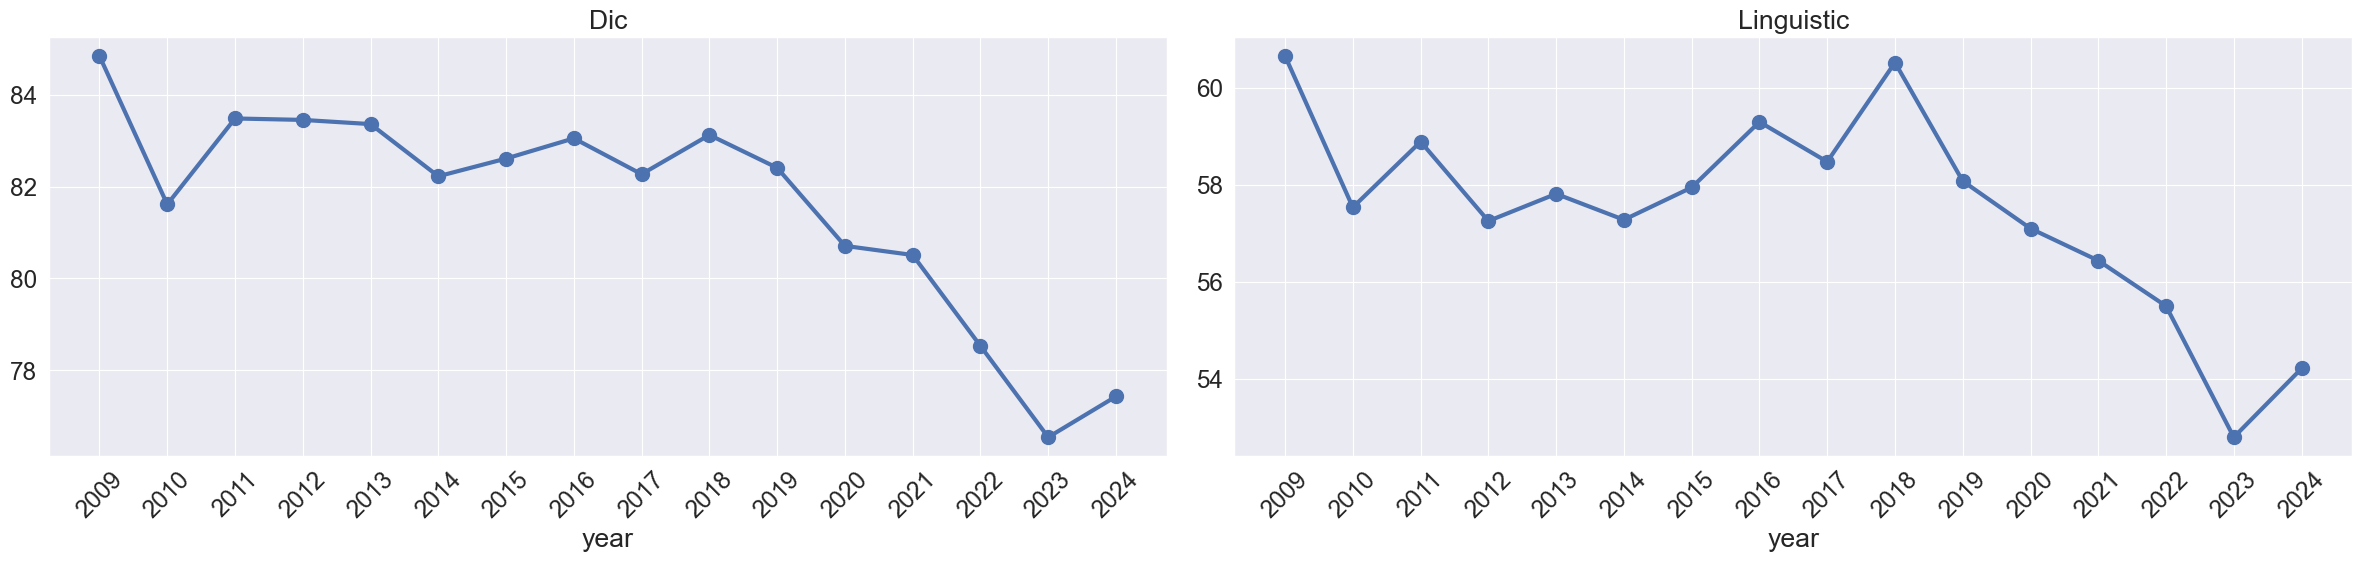

In [27]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, 
    figsize=(24, 6), 
    squeeze=False)

axes_flat: list[Axes] = axes.flatten()

for i, col in enumerate(["Dic", "Linguistic"]):
    ax = axes_flat[i]
    
    ax.plot(all_types_summary_df.index, all_types_summary_df[col], marker="o", lw=3, markersize=10)
    
    ax.set_title(col)
    
    ax.set_xlabel("year")
    ax.set_xticks(range(2009, 2025))
    ax.tick_params(axis="x", rotation=45)
    
    ax.grid(True)

plt.tight_layout()

plt.draw()
plt.savefig("./visualization/LIWC/paper_all_types_dic_linguistic.png")

plt.show()

Analytic, Clout, Authentic, Tone

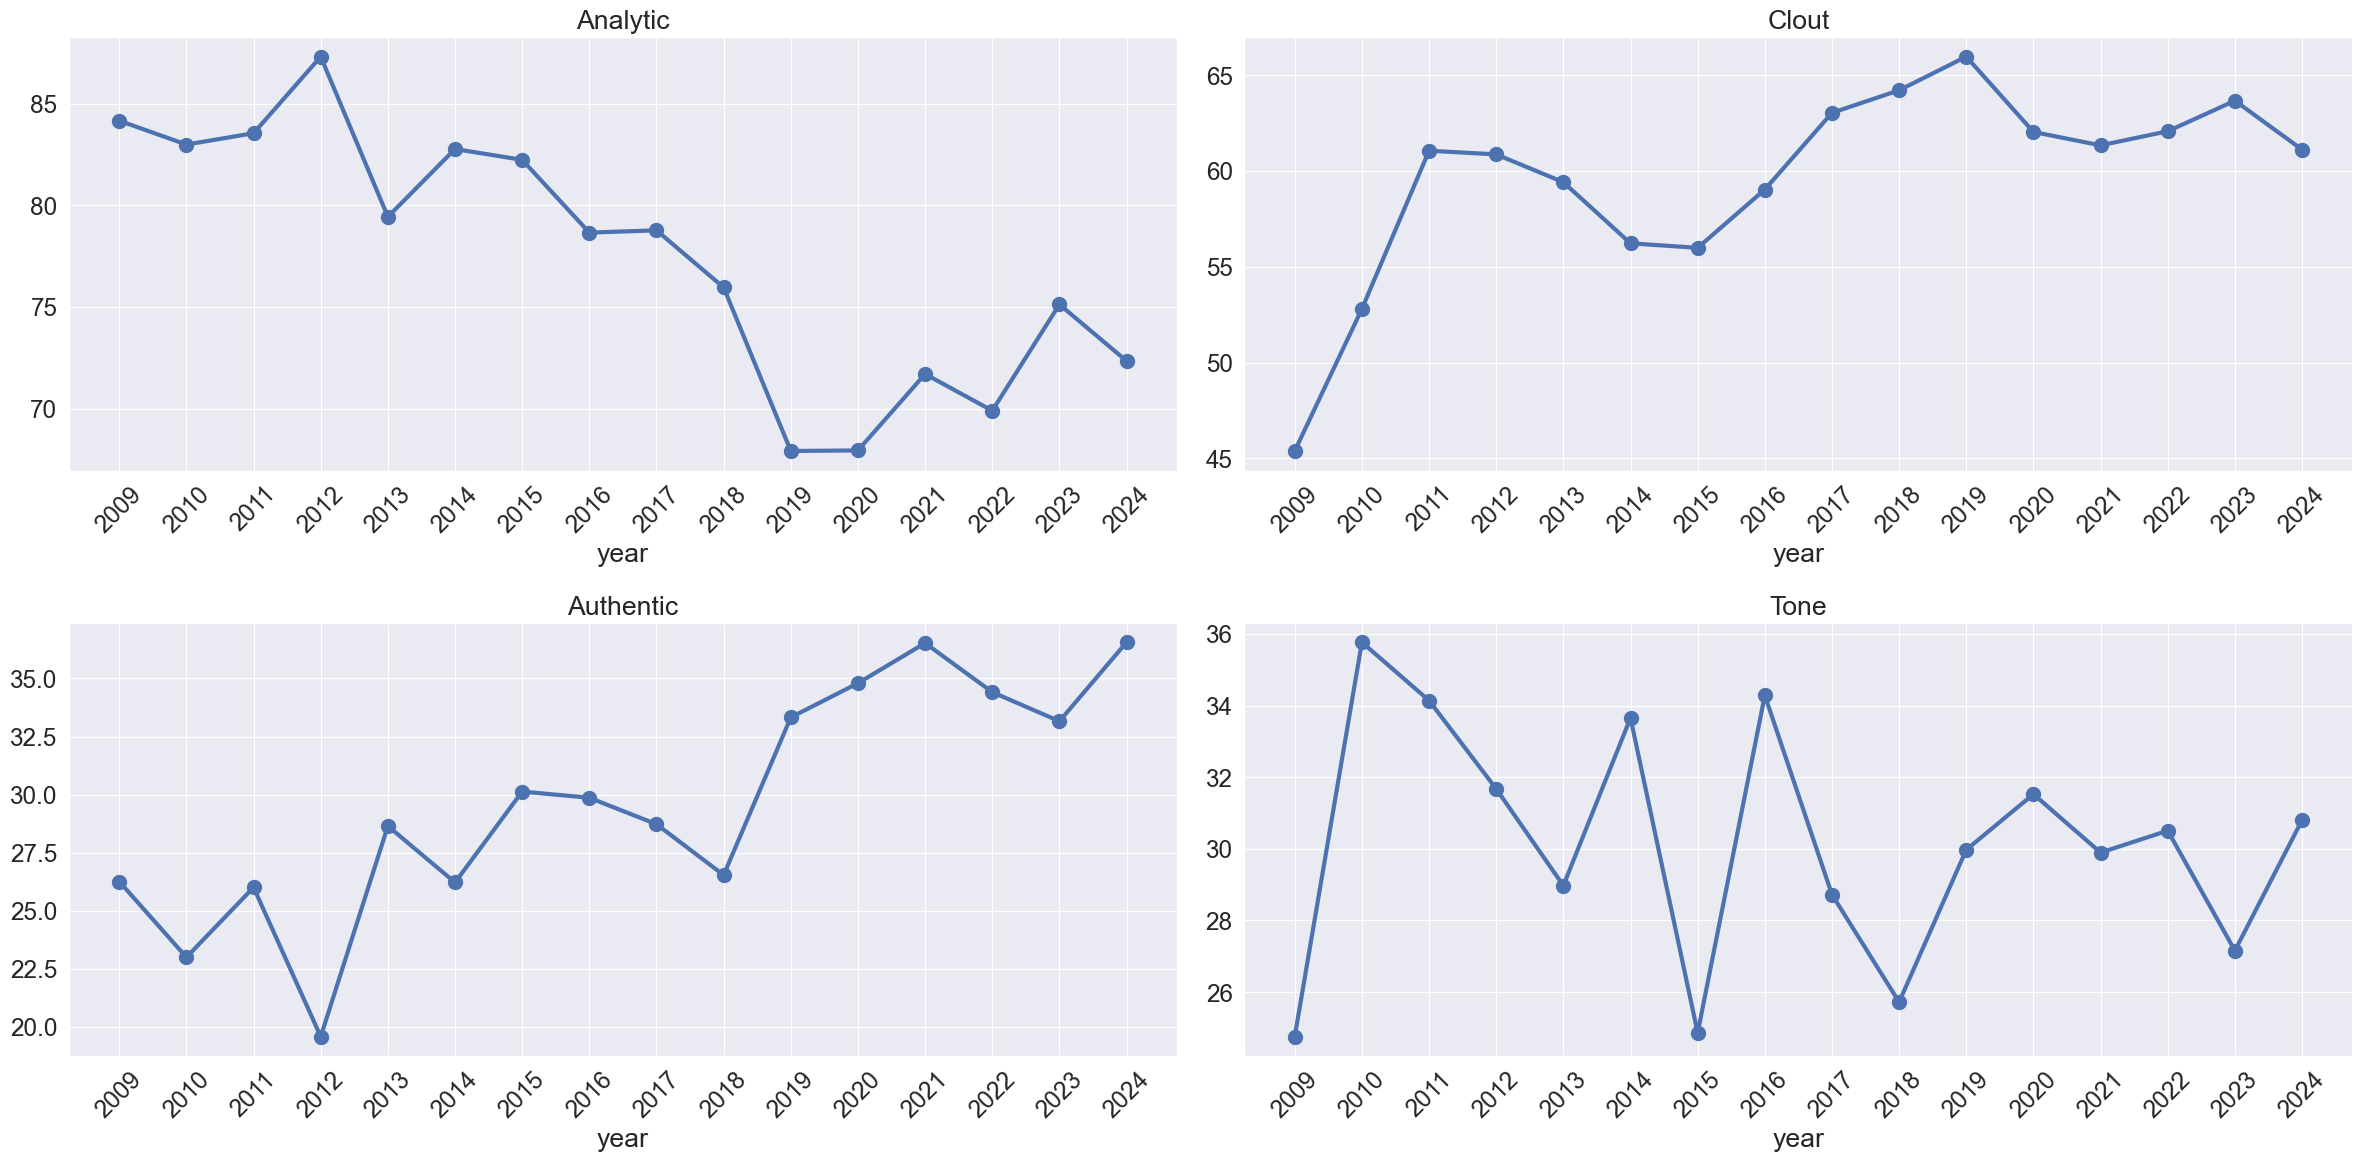

In [28]:
fig, axes = plt.subplots(
    nrows=2, ncols=2, 
    figsize=(24, 12), 
    squeeze=False)

axes_flat: list[Axes] = axes.flatten()

for i, col in enumerate(["Analytic", "Clout", "Authentic", "Tone"]):
    ax = axes_flat[i]
    
    ax.plot(all_types_summary_df.index, all_types_summary_df[col], marker="o", lw=3, markersize=10)
    
    ax.set_title(col)
    
    ax.set_xlabel("year")
    ax.set_xticks(range(2009, 2025))
    ax.tick_params(axis="x", rotation=45)
    
    ax.grid(True)

plt.tight_layout()

plt.draw()
plt.savefig("./visualization/LIWC/paper_all_types_analytic_clout_authentic_tone.png")

plt.show()